In [4]:
!pip install pandas numpy scikit-learn lightgbm joblib matplotlib seaborn tensorflow pvlib



In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import lightgbm as lgb
# Optional for deep learning
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [6]:
import pandas as pd

nasa_file = "/POWER_Point_Daily_20220101_20241231_028d61N_077d21E_LST.csv"

# Step 1: Skip both headers
# The actual data starts after '-END HEADER-' row, which is row 13 (index 12)
# The header information spans the first 13 rows, so we skip the first 12 rows (index 0-11)
# The actual column names are in row 14 (index 13), and the data starts from row 15 (index 14)
# We need to skip the first 13 rows to get the column names in the header row
nasa_df = pd.read_csv(nasa_file, skiprows=13)

# Step 2: Check column names
print(nasa_df.columns)
print(nasa_df.head())
# Step 2a: Skip metadata rows
nasa_df = pd.read_csv(nasa_file, skiprows=13)  # '-END HEADER-' is at row 13

# Step 2b: Clean column names
nasa_df.columns = nasa_df.columns.str.replace('\xa0', '').str.strip()
print("Columns after cleaning:", list(nasa_df.columns))

# --------------------------
# Step 3: Create timestamp column
nasa_df["timestamp"] = pd.to_datetime(
    nasa_df[["YEAR", "MO", "DY"]].astype(str).agg("-".join, axis=1),
    format="%Y-%m-%d"
)
df = nasa_df.rename(columns={
    "ALLSKY_SFC_SW_DWN": "irradiance_Wm2",
    "T2M": "temperature_C",
    "RH2M": "humidity",
    "WS2M": "wind_speed"
})
df["cloud_pct"] = 100 - (df["irradiance_Wm2"] / df["irradiance_Wm2"].max() * 100)

# Keep only necessary columns
df = df[["timestamp", "irradiance_Wm2", "temperature_C", "humidity", "wind_speed", "cloud_pct"]]
def baseline_irradiance_to_kwh(irradiance_wm2, panel_kWp=5.0, eff_pct=18.0, temp_c=25):
    temp_loss = np.maximum(0, temp_c - 25) * 0.005
    temp_factor = 1 - temp_loss
    p_kw = panel_kWp * (irradiance_wm2 / 1000.0) * (eff_pct / 100.0) * temp_factor
    return np.clip(p_kw, 0.0, panel_kWp)

df["baseline_kWh"] = baseline_irradiance_to_kwh(
    df["irradiance_Wm2"],
    panel_kWp=5.0,
    eff_pct=18.0,
    temp_c=df["temperature_C"]
)

# Use baseline as target for model training
df["actual_generation_kWh"] = df["baseline_kWh"]

# --------------------------
# Step 6: Check the prepared dataset
print(df.head())
print(df.tail())
print("Columns ready for modeling:", df.columns)


Index(['YEAR', 'MO', 'DY', 'ALLSKY_SFC_SW_DWN', 'T2M', 'RH2M', 'WS2M',
       'CLRSKY_KT'],
      dtype='object')
   YEAR  MO  DY  ALLSKY_SFC_SW_DWN    T2M   RH2M  WS2M  CLRSKY_KT
0  2022   1   1             3.2326  12.15  51.69  1.00       0.56
1  2022   1   2             2.9018  12.78  53.86  1.25       0.53
2  2022   1   3             3.1644  13.44  50.34  1.11       0.56
3  2022   1   4             2.7694  15.64  48.20  0.97       0.57
4  2022   1   5             0.7740  13.32  68.57  1.84       0.51
Columns after cleaning: ['YEAR', 'MO', 'DY', 'ALLSKY_SFC_SW_DWN', 'T2M', 'RH2M', 'WS2M', 'CLRSKY_KT']
   timestamp  irradiance_Wm2  temperature_C  humidity  wind_speed  cloud_pct  \
0 2022-01-01          3.2326          12.15     51.69        1.00  59.531291   
1 2022-01-02          2.9018          12.78     53.86        1.25  63.672555   
2 2022-01-03          3.1644          13.44     50.34        1.11  60.385082   
3 2022-01-04          2.7694          15.64     48.20        0.97  6

In [7]:

# Step 7: Feature Engineering
df["hour"] = df["timestamp"].dt.hour
df["dayofyear"] = df["timestamp"].dt.dayofyear
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

# Features and target
features = ["irradiance_Wm2", "temperature_C", "cloud_pct", "humidity", "wind_speed",
            "hour_sin", "hour_cos", "dayofyear"]
target = "actual_generation_kWh"

X = df[features]
y = df[target]

In [8]:
# Step 8: Train-Test Split
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import lightgbm as lgb
import numpy as np

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


In [9]:
import lightgbm as lgb

# Training dataset
lgb_train = lgb.Dataset(X_train, y_train)
lgb_test = lgb.Dataset(X_test, y_test, reference=lgb_train)

params = {
    "objective": "regression",
    "metric": "rmse",
    "learning_rate": 0.1,
    "num_leaves": 31,
    "verbose": -1
}

# Use early stopping via callbacks
model = lgb.train(
    params,
    lgb_train,
    num_boost_round=200,
    valid_sets=[lgb_test],
    callbacks=[lgb.early_stopping(stopping_rounds=20)]
)

# Predict
y_pred = model.predict(X_test)


Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[147]	valid_0's rmse: 5.96222e-05


In [10]:
y_pred = model.predict(X_test)

# Evaluate
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print(f"LightGBM RMSE: {rmse:.3f}, R2: {r2:.3f}")

LightGBM RMSE: 0.000, R2: 0.997


In [11]:
# Step 10: Battery Simulator
battery_capacity_kWh = 10      # User input
current_soc_pct = 50           # User input
depth_of_discharge_pct = 80    # User input
round_trip_efficiency_pct = 90 # User input
load_kWh = 2                   # Optional user input per timestep

usable_capacity = battery_capacity_kWh * (depth_of_discharge_pct / 100)
soc = current_soc_pct / 100 * usable_capacity
soc_list, overflow_list, shortfall_list = [], [], []

for gen in y_pred:
    # Charge battery
    soc += gen * (round_trip_efficiency_pct / 100)
    overflow = 0
    if soc > usable_capacity:
        overflow = soc - usable_capacity
        soc = usable_capacity
    # Discharge battery for load
    soc -= load_kWh
    shortfall = 0
    if soc < 0:
        shortfall = abs(soc)
        soc = 0
    soc_list.append(soc / usable_capacity * 100)
    overflow_list.append(overflow)
    shortfall_list.append(shortfall)

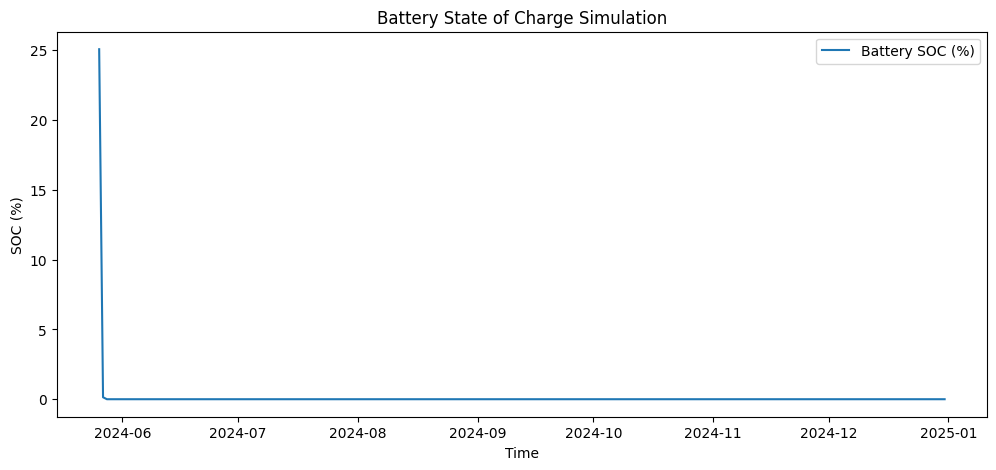

Total Overflow: 0.00 kWh
Total Shortfall: 435.24 kWh
Predictions exported to 'solarcast_predictions.csv'


In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df["timestamp"].iloc[-len(y_pred):], soc_list, label="Battery SOC (%)")
plt.xlabel("Time")
plt.ylabel("SOC (%)")
plt.title("Battery State of Charge Simulation")
plt.legend()
plt.show()

print(f"Total Overflow: {sum(overflow_list):.2f} kWh")
print(f"Total Shortfall: {sum(shortfall_list):.2f} kWh")

# --------------------------
# Step 12: Export predictions
output_df = pd.DataFrame({
    "timestamp": df["timestamp"].iloc[-len(y_pred):],
    "predicted_generation_kWh": y_pred,
    "battery_SOC_pct": soc_list,
    "overflow_kWh": overflow_list,
    "shortfall_kWh": shortfall_list
})

output_df.to_csv("solarcast_predictions.csv", index=False)
print("Predictions exported to 'solarcast_predictions.csv'")

Total CO2 Avoided: 0.69 kg
Total Cost Savings: ₹5.91


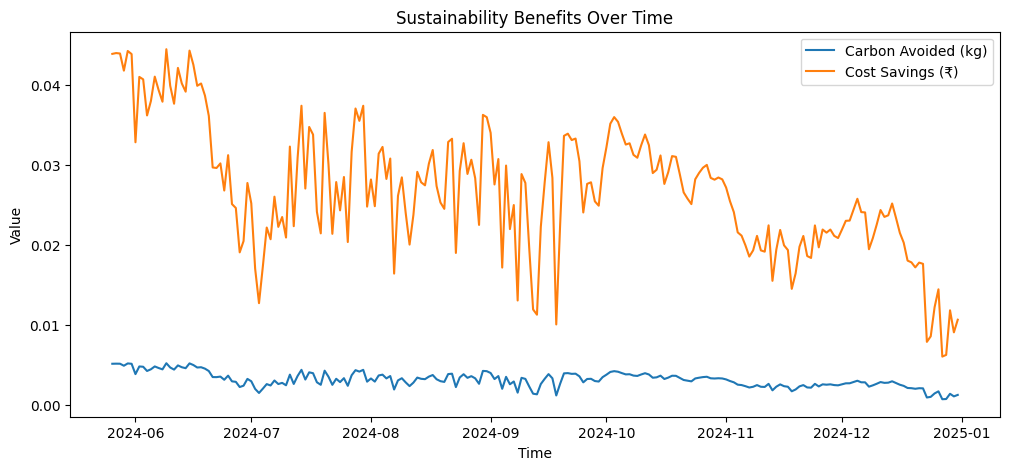

Updated predictions with sustainability benefits saved as 'solarcast_predictions_with_sustainability.csv'


In [13]:
# --------------------------
# Step 13: Sustainability Benefits

# User inputs / assumptions
grid_emission_factor = 0.82  # kg CO2 per kWh (India avg, change per region)
grid_electricity_price = 7.0  # Rs per kWh (adjust as per your local rates)

# Calculate carbon avoided (kg CO2)
output_df["carbon_avoided_kg"] = output_df["predicted_generation_kWh"] * grid_emission_factor

# Calculate cost savings (Rs)
output_df["cost_savings"] = output_df["predicted_generation_kWh"] * grid_electricity_price

# Summarize totals
total_carbon = output_df["carbon_avoided_kg"].sum()
total_savings = output_df["cost_savings"].sum()

print(f"Total CO2 Avoided: {total_carbon:.2f} kg")
print(f"Total Cost Savings: ₹{total_savings:.2f}")

# Optional: Visualize carbon avoided & cost savings
plt.figure(figsize=(12,5))
plt.plot(output_df["timestamp"], output_df["carbon_avoided_kg"], label="Carbon Avoided (kg)")
plt.plot(output_df["timestamp"], output_df["cost_savings"], label="Cost Savings (₹)")
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Sustainability Benefits Over Time")
plt.legend()
plt.show()

# Save updated predictions with sustainability benefits
output_df.to_csv("solarcast_predictions_with_sustainability.csv", index=False)
print("Updated predictions with sustainability benefits saved as 'solarcast_predictions_with_sustainability.csv'")


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 6s 78ms/step - loss: 0.2089 - val_loss: 0.0146
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - loss: 0.0217 - val_loss: 0.0182
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0170 - val_loss: 0.0131
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0162 - val_loss: 0.0132
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 0.0133 - val_loss: 0.0123
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - loss: 0.0146 - val_loss: 0.0131
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.0142 - val_loss: 0.0112
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - loss: 0.0153 - val_loss: 0.0117
Epoch 9/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 0.0164 - val_loss: 0.0109
Epoch 10/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0155 - val_loss: 0.0110
Epoch 11/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0132 - val_loss: 0.0104
Epoch 12/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.0131 - val_l

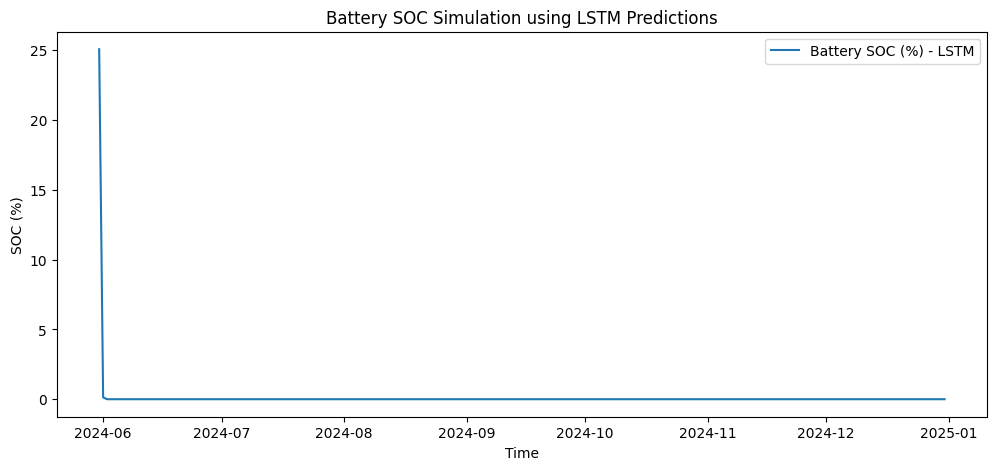

Total CO2 Avoided (LSTM): 0.64 kg
Total Cost Savings (LSTM): ₹5.47
LSTM predictions with battery & sustainability exported to 'solarcast_lstm_predictions.csv'


In [14]:
# --------------------------
# Step 14: Deep Learning (LSTM) Integration

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.model_selection import train_test_split


# Step 14a: Scale features
scaler = MinMaxScaler()
scaled_features = scaler.fit_transform(df[features])
scaled_target = df["actual_generation_kWh"].values.reshape(-1, 1)
scaled_target = MinMaxScaler().fit_transform(scaled_target)


# Step 14b: Create sequences for LSTM
window_size = 24  # past 24 hours -> predict next hour
X_seq, y_seq = [], []

for i in range(len(df) - window_size):
    X_seq.append(scaled_features[i:i+window_size])
    y_seq.append(scaled_target[i+window_size])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

# Train-test split
split_idx = int(0.8 * len(X_seq))
X_train, X_test = X_seq[:split_idx], X_seq[split_idx:]
y_train, y_test = y_seq[:split_idx], y_seq[split_idx:]


# Step 14c: Build LSTM model
model_lstm = Sequential([
    LSTM(64, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dense(32, activation='relu'),
    Dense(1)
])
model_lstm.compile(optimizer='adam', loss='mse')

# Train LSTM
history = model_lstm.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=32,
    verbose=1
)

# Step 14d: Predict with LSTM
y_pred_lstm_scaled = model_lstm.predict(X_test)
# Inverse scale
y_pred_lstm = MinMaxScaler().fit(df["actual_generation_kWh"].values.reshape(-1,1)).inverse_transform(y_pred_lstm_scaled)

# Prepare timestamps for prediction alignment
timestamps_lstm = df["timestamp"].iloc[-len(y_pred_lstm):]
y_pred_lstm_inv = y_pred_lstm.flatten()  # already scaled back to kWh
y_test_inv = y_test.flatten()            # if scaled, inverse_transform first

# Assuming y_test_lstm and y_pred_lstm_inv are in kWh (inverse scaled)
# y_test_lstm: true solar generation values
# y_pred_lstm_inv: predicted solar generation from LSTM
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Inverse scale y_test for LSTM if needed
# If you scaled y_test before training, apply inverse_transform
# Otherwise, if it's already in kWh, just use y_test[-len(y_pred_lstm):]
y_test_lstm_inv = df["actual_generation_kWh"].iloc[-len(y_pred_lstm):].values
y_pred_lstm_inv = y_pred_lstm.flatten()

# Compute metrics
rmse_lstm = np.sqrt(mean_squared_error(y_test_lstm_inv, y_pred_lstm_inv))
mae_lstm = mean_absolute_error(y_test_lstm_inv, y_pred_lstm_inv)
r2_lstm = r2_score(y_test_lstm_inv, y_pred_lstm_inv)

print(f"LSTM Metrics:")
print(f"RMSE: {rmse_lstm:.3f} kWh")
print(f"MAE: {mae_lstm:.3f} kWh")
print(f"R² Score: {r2_lstm:.3f}")




# Step 14e: Battery SOC simulation with LSTM predictions
battery_capacity_kWh = 10
current_soc_pct = 50
depth_of_discharge_pct = 80
round_trip_efficiency_pct = 90
load_kWh = 2

usable_capacity = battery_capacity_kWh * (depth_of_discharge_pct / 100)
soc = current_soc_pct / 100 * usable_capacity
soc_list, overflow_list, shortfall_list = [], [], []

for gen in y_pred_lstm.flatten():
    soc += gen * (round_trip_efficiency_pct / 100)
    overflow = 0
    if soc > usable_capacity:
        overflow = soc - usable_capacity
        soc = usable_capacity
    soc -= load_kWh
    shortfall = 0
    if soc < 0:
        shortfall = abs(soc)
        soc = 0
    soc_list.append(soc / usable_capacity * 100)
    overflow_list.append(overflow)
    shortfall_list.append(shortfall)


# Step 14f: Visualize SOC
plt.figure(figsize=(12,5))
plt.plot(timestamps_lstm, soc_list, label="Battery SOC (%) - LSTM")
plt.xlabel("Time")
plt.ylabel("SOC (%)")
plt.title("Battery SOC Simulation using LSTM Predictions")
plt.legend()
plt.show()


# Step 14g: Sustainability Benefits (Carbon & Cost)
grid_emission_factor = 0.82  # kg CO2/kWh
grid_electricity_price = 7.0 # Rs/kWh

carbon_avoided = y_pred_lstm.flatten() * grid_emission_factor
cost_savings = y_pred_lstm.flatten() * grid_electricity_price

print(f"Total CO2 Avoided (LSTM): {carbon_avoided.sum():.2f} kg")
print(f"Total Cost Savings (LSTM): ₹{cost_savings.sum():.2f}")

# --------------------------
# Step 14h: Export final LSTM predictions
output_lstm_df = pd.DataFrame({
    "timestamp": timestamps_lstm,
    "predicted_generation_kWh": y_pred_lstm.flatten(),
    "battery_SOC_pct": soc_list,
    "overflow_kWh": overflow_list,
    "shortfall_kWh": shortfall_list,
    "carbon_avoided_kg": carbon_avoided,
    "cost_savings": cost_savings
})
output_lstm_df.to_csv("solarcast_lstm_predictions.csv", index=False)
print("LSTM predictions with battery & sustainability exported to 'solarcast_lstm_predictions.csv'")
